In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow.keras as tf

In [2]:
mnist = tf.datasets.mnist
(xtrain,ytrain),(xtest,ytest) = mnist.load_data()

11490434/11490434 [==============================] - 0s 0us/step


In [3]:
print(xtrain.shape)
print(ytrain.shape)
print(xtest.shape)
print(ytest.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [4]:
xtrain[3]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0, 124, 253, 255,  63,   0,   0,   0,   0,
          0,   0],
       [  

In [5]:
ytrain[3]

1

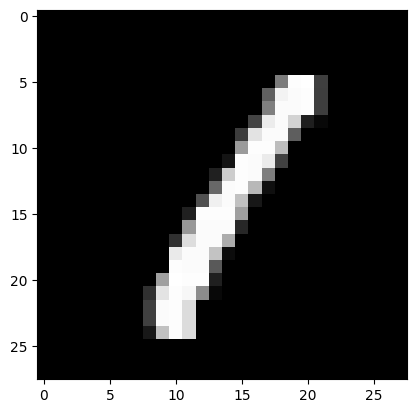

In [6]:
plt.imshow(xtrain[3],cmap='gray');

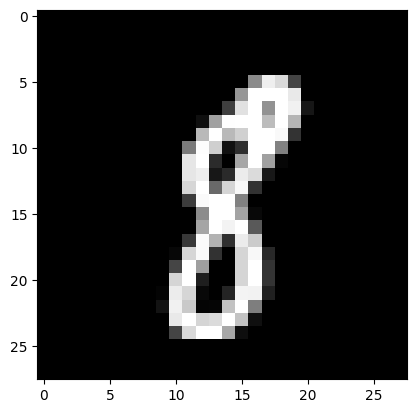

In [7]:
plt.imshow(xtrain[300],cmap='gray');

In [8]:
ytrain[300]

8

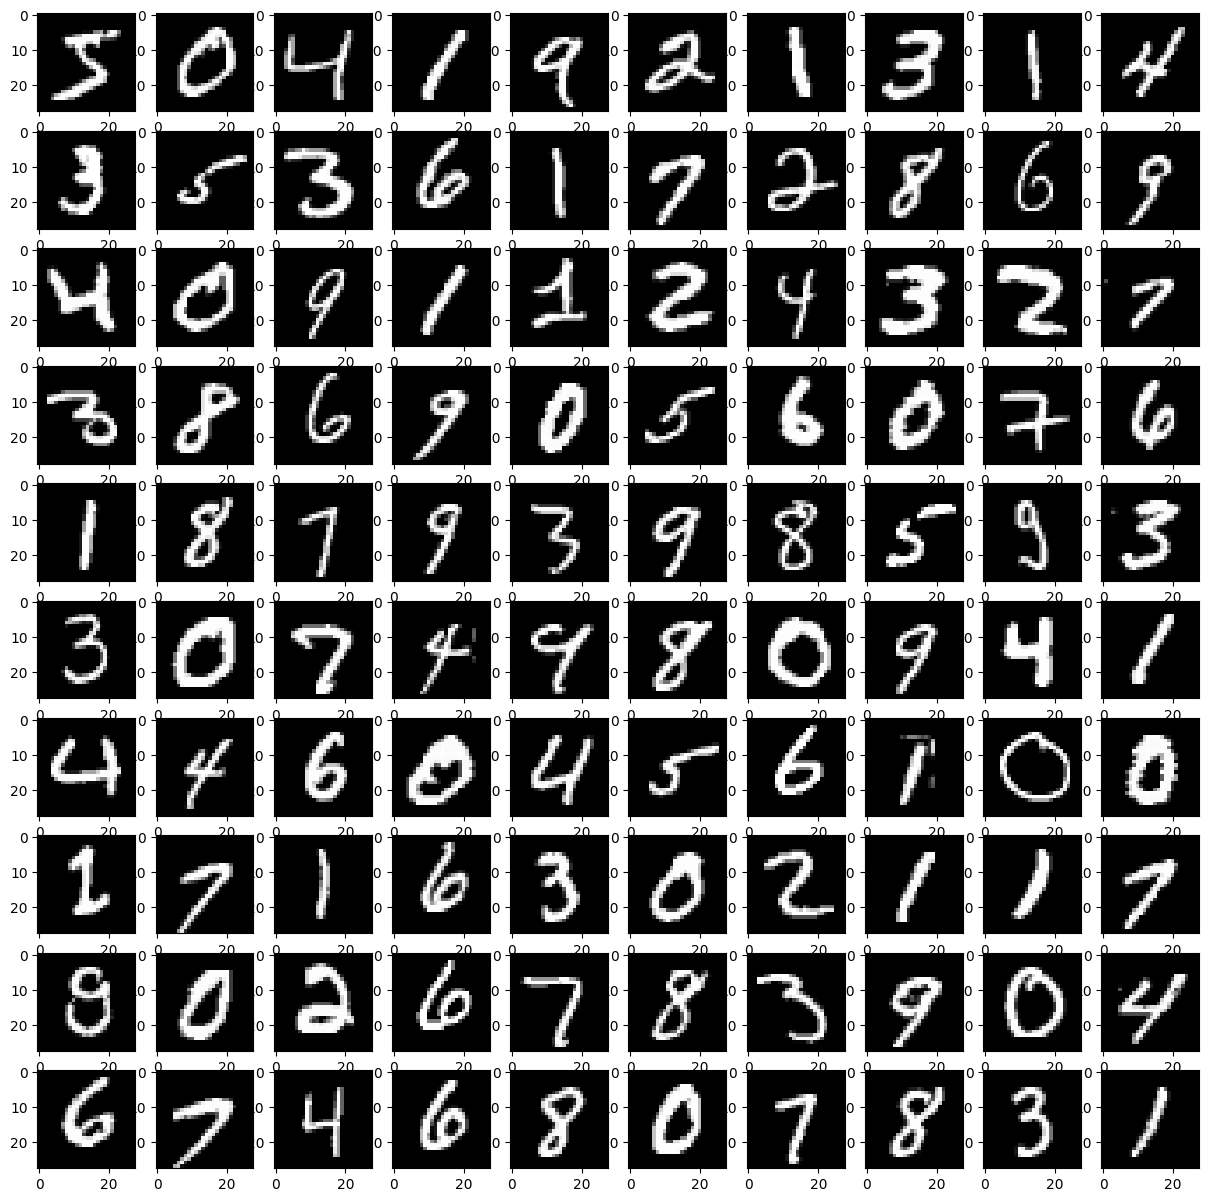

In [9]:
plt.figure(figsize=(15,15))
for i in range(100):
  plt.subplot(10,10,i+1)
  plt.imshow(xtrain[i],cmap='gray')
plt.show()

In [10]:
xtrain = xtrain/255
xtest = xtest/255

In [11]:
xtrain[300]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

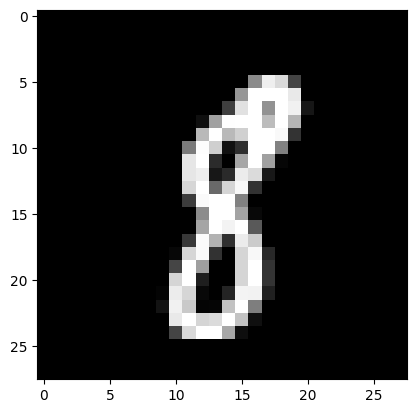

In [12]:
plt.imshow(xtrain[300],cmap='gray');

In [13]:
### ANN

In [14]:
model = tf.models.Sequential()
## add the layers
model.add(tf.layers.Flatten())   ## input
model.add(tf.layers.Dense(784,activation='relu'))  ## hidden
model.add(tf.layers.Dense(10,activation='softmax'))  ## output
## compile the model
model.compile(loss="sparse_categorical_crossentropy",optimizer="adam",metrics=["accuracy"])

In [15]:
### Train
model.fit(xtrain,ytrain,epochs=20,validation_data=(xtest,ytest))

Epoch 1/20
1875/1875 [==============================] - 13s 4ms/step - loss: 0.1912 - accuracy: 0.9420 - val_loss: 0.1130 - val_accuracy: 0.9653
Epoch 2/20
1875/1875 [==============================] - 9s 5ms/step - loss: 0.0768 - accuracy: 0.9764 - val_loss: 0.0728 - val_accuracy: 0.9763
Epoch 3/20
1875/1875 [==============================] - 5s 3ms/step - loss: 0.0490 - accuracy: 0.9841 - val_loss: 0.0706 - val_accuracy: 0.9773
Epoch 4/20
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0347 - accuracy: 0.9887 - val_loss: 0.0738 - val_accuracy: 0.9775
Epoch 5/20
1875/1875 [==============================] - 5s 3ms/step - loss: 0.0260 - accuracy: 0.9913 - val_loss: 0.0619 - val_accuracy: 0.9817
Epoch 6/20
1875/1875 [==============================] - 5s 3ms/step - loss: 0.0217 - accuracy: 0.9930 - val_loss: 0.0784 - val_accuracy: 0.9784
Epoch 7/20
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0158 - accuracy: 0.9944 - val_loss: 0.0683 - val_accuracy

In [17]:
ytest

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

In [ ]:
ypred = model.predict(xtest)
ypred

In [19]:
ytest[0]

7

In [20]:
ypred[0]

array([7.3006050e-22, 7.8956856e-19, 5.7665172e-21, 1.4717275e-14,
       3.3714105e-24, 1.1920196e-20, 3.8547424e-30, 1.0000000e+00,
       6.7155165e-19, 3.4449616e-13], dtype=float32)

In [21]:
np.argmax(ypred[0])

7

In [22]:
ypred = np.argmax(ypred,axis=1)
ypred

array([7, 2, 1, ..., 4, 5, 6])

In [23]:
ytest

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

In [25]:
from sklearn.metrics import confusion_matrix,accuracy_score

In [26]:
accuracy_score(ytest,ypred)

0.9801

In [27]:
confusion_matrix(ytest,ypred)

array([[ 974,    1,    0,    1,    0,    1,    2,    1,    0,    0],
       [   0, 1127,    0,    2,    0,    0,    2,    1,    3,    0],
       [   2,    1, 1008,    1,    2,    1,    2,    8,    7,    0],
       [   0,    0,    1,  996,    1,    5,    0,    5,    2,    0],
       [   2,    3,    5,    0,  962,    0,    3,    0,    0,    7],
       [   1,    0,    0,    9,    1,  877,    2,    0,    2,    0],
       [   2,    3,    0,    1,    4,    6,  942,    0,    0,    0],
       [   1,    6,    6,    1,    0,    0,    0, 1008,    2,    4],
       [   1,    2,    2,   10,    2,    3,    2,    5,  945,    2],
       [   3,    3,    0,    9,    9,    8,    0,   13,    2,  962]])

In [28]:
### Save your model in a file

In [29]:
model.save("mnist.h5")

In [30]:
mymodel = tf.models.load_model("/content/mnist.h5")

(28, 28)
1/1 [==============================] - 0s 56ms/step
Predicted Digit is -  2


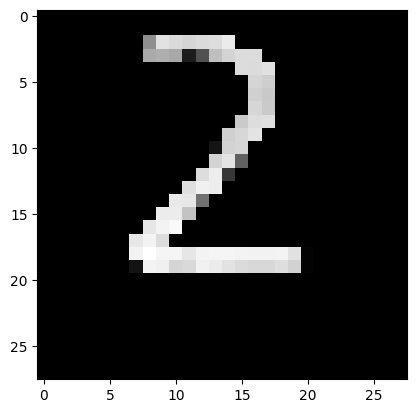

In [38]:
import cv2
img = cv2.imread("/content/2.png")
img = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
img = cv2.resize(img,(28,28))
img = cv2.bitwise_not(img)
img = img/255
print(img.shape)
print("Predicted Digit is - ",np.argmax(mymodel.predict(np.array([img]))))
plt.imshow(img,cmap='gray');

(28, 28)
1/1 [==============================] - 0s 29ms/step
Predicted Digit is -  3


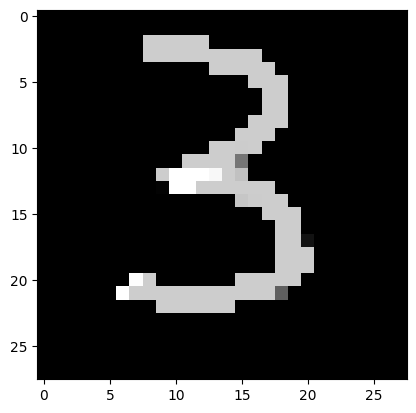

In [39]:
import cv2
img = cv2.imread("/content/3.png")
img = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
img = cv2.resize(img,(28,28))
img = cv2.bitwise_not(img)
img = img/255
print(img.shape)
print("Predicted Digit is - ",np.argmax(mymodel.predict(np.array([img]))))
plt.imshow(img,cmap='gray');